# Results Summary

This notebook reads the aggregate CSV files in `results/analysis` and compares the downstream MLP heads with simple baselines.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent.parent

DATASET = ROOT / "data" / "correctness_dataset"
CANDIDATES = DATASET / "candidates"
FEATURES = DATASET / "features"
HEADS = ROOT / "models" / "correctness_heads"
RESULTS = ROOT / "results" / "analysis"

print(f"Repository root: {ROOT}")

Repository root: /home/bernardod/desktop/research/planfm-validity


In [5]:
story = pd.read_csv(RESULTS / "story_summary.csv")
print(story.shape)
story.head()

(24, 10)


,method,family,split,num_runs,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,MeanBaseline,baseline,test-extrapolation,3,0.262807,0.0,0.303018,0.0,-0.030171,0.0
1,MeanBaseline,baseline,test-interpolation,3,0.277203,0.0,0.320281,0.0,-0.002461,0.0
2,MeanBaseline,baseline,train,3,0.270863,0.0,0.313727,0.0,0.000000,0.0
3,MeanBaseline,baseline,validation,3,0.255000,0.0,0.301081,0.0,-0.016466,0.0
4,PlanLengthBaseline,baseline,test-extrapolation,3,2.550361,0.0,3.778683,0.0,-159.196732,0.0


In [14]:
mlp = story[story["method"].str.startswith("mlp")].copy()
cols = ["family", "split", "num_runs", "MAE_mean", "RMSE_mean", "R2_mean"]
mlp[cols].sort_values(["split", "family"])

,family,split,num_runs,MAE_mean,RMSE_mean,R2_mean
8,ad_lstm_wl_delta,test-extrapolation,3,0.184874,0.250774,0.292755
12,ad_xgb_wl_delta,test-extrapolation,3,0.167557,0.240983,0.348117
16,dd_lstm_shortest_path_delta,test-extrapolation,3,0.173865,0.234152,0.384410
20,dd_xgb_wl_delta,test-extrapolation,3,0.201636,0.254146,0.274462
9,ad_lstm_wl_delta,test-interpolation,3,0.093152,0.157354,0.757934
13,ad_xgb_wl_delta,test-interpolation,3,0.117815,0.197463,0.616834
17,dd_lstm_shortest_path_delta,test-interpolation,3,0.112400,0.184462,0.666284
21,dd_xgb_wl_delta,test-interpolation,3,0.108934,0.177624,0.691652
10,ad_lstm_wl_delta,train,3,0.047952,0.078440,0.936439
14,ad_xgb_wl_delta,train,3,0.057315,0.094958,0.906348


In [15]:
baselines = story[~story["method"].str.startswith("mlp")].copy()
baselines[["method", "family", "split", "MAE_mean", "RMSE_mean", "R2_mean"]].sort_values(["method", "split"])

,method,family,split,MAE_mean,RMSE_mean,R2_mean
0,MeanBaseline,baseline,test-extrapolation,0.262807,0.303018,-0.030171
1,MeanBaseline,baseline,test-interpolation,0.277203,0.320281,-0.002461
2,MeanBaseline,baseline,train,0.270863,0.313727,0.000000
3,MeanBaseline,baseline,validation,0.255000,0.301081,-0.016466
4,PlanLengthBaseline,baseline,test-extrapolation,2.550361,3.778683,-159.196732
5,PlanLengthBaseline,baseline,test-interpolation,0.263914,0.306298,0.083161
6,PlanLengthBaseline,baseline,train,0.267093,0.306858,0.043306
7,PlanLengthBaseline,baseline,validation,0.262769,0.311644,-0.089040


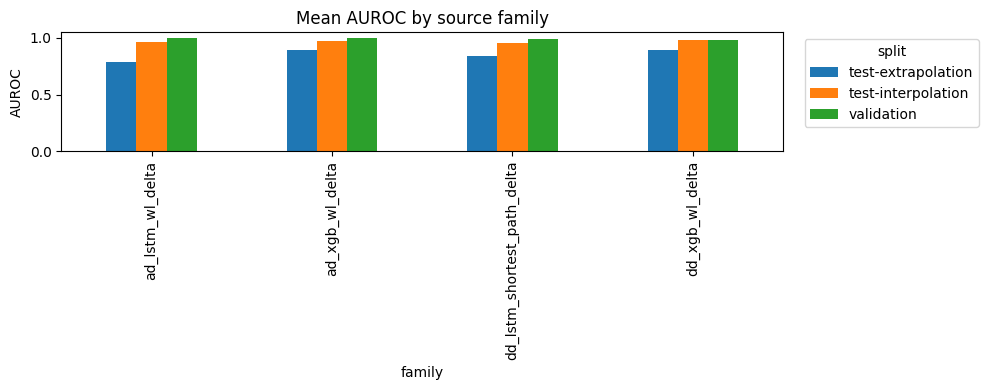

In [ ]:
import matplotlib.pyplot as plt

plot_df = mlp[mlp["split"].isin(["validation", "test-interpolation", "test-extrapolation"])].copy()
pivot = plot_df.pivot(index="family", columns="split", values="MAE")
ax = pivot.plot(kind="bar", figsize=(10, 4), ylim=(0.0, 1.05))
ax.set_title("Mean AUROC by source family")
ax.set_ylabel("AUROC")
ax.legend(title="split", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

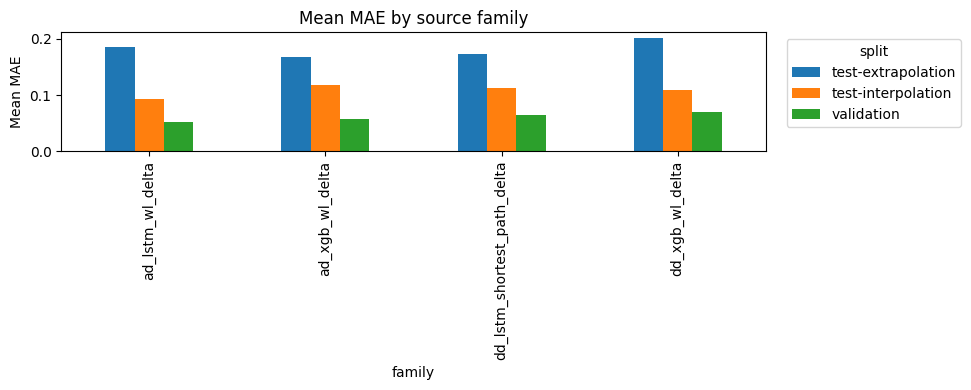

In [23]:
import matplotlib.pyplot as plt

plot_df = mlp[
    mlp["split"].isin(["validation", "test-interpolation", "test-extrapolation"])
].copy()

pivot = plot_df.pivot(index="family", columns="split", values="MAE_mean")
ax = pivot.plot(kind="bar", figsize=(10, 4))
ax.set_title("Mean MAE by source family")
ax.set_ylabel("Mean MAE")
ax.legend(title="split", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [24]:
# Show the best MLP family per evaluation split by MAE_mean.
best = (
    mlp[mlp["split"].isin(["validation", "test-interpolation", "test-extrapolation"])]
    .sort_values("MAE_mean", ascending=False)
    .groupby("split")
    .head(1)
    [["split", "family", "MAE_mean", "RMSE_mean", "R2_mean"]]
)
best

,split,family,MAE_mean,RMSE_mean,R2_mean
20,test-extrapolation,dd_xgb_wl_delta,0.201636,0.254146,0.274462
13,test-interpolation,ad_xgb_wl_delta,0.117815,0.197463,0.616834
23,validation,dd_xgb_wl_delta,0.069777,0.123216,0.829572
